In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

In [2]:
ratings = pd.read_csv('../data/preprocessed/ratings_cleaned.csv')
movies = pd.read_csv('../data/preprocessed/movies_cleaned.csv')

In [3]:
# Convert the text back into lists for the 'genres' column
# ast.literal_eval safely converts the string "['A', 'B']" into an actual list ['A', 'B']
movies['genres'] = movies['genres'].apply(ast.literal_eval)

print(f"Data loaded! Ratings: {len(ratings)}, Movies: {len(movies)}")

Data loaded! Ratings: 989523, Movies: 9222


In [4]:
movies.sample(3)

,movieId,title,genres
8463,81383,Heartbreaker (L'Arnacoeur) (2010),"[Comedy, Romance]"
6714,32179,Elevator to the Gallows (a.k.a. Frantic) (Asce...,"[Crime, Drama, Thriller]"
3722,4493,Critters 2: The Main Course (1988),"[Comedy, Horror, Sci-Fi]"


In [5]:
ratings.sample(3)

,userId,movieId,rating,timestamp
698197,97735,2761,2.0,2006-03-21 15:14:55
277797,37577,1253,4.0,2008-10-30 16:41:30
102755,14469,111360,4.0,2014-11-28 21:07:05


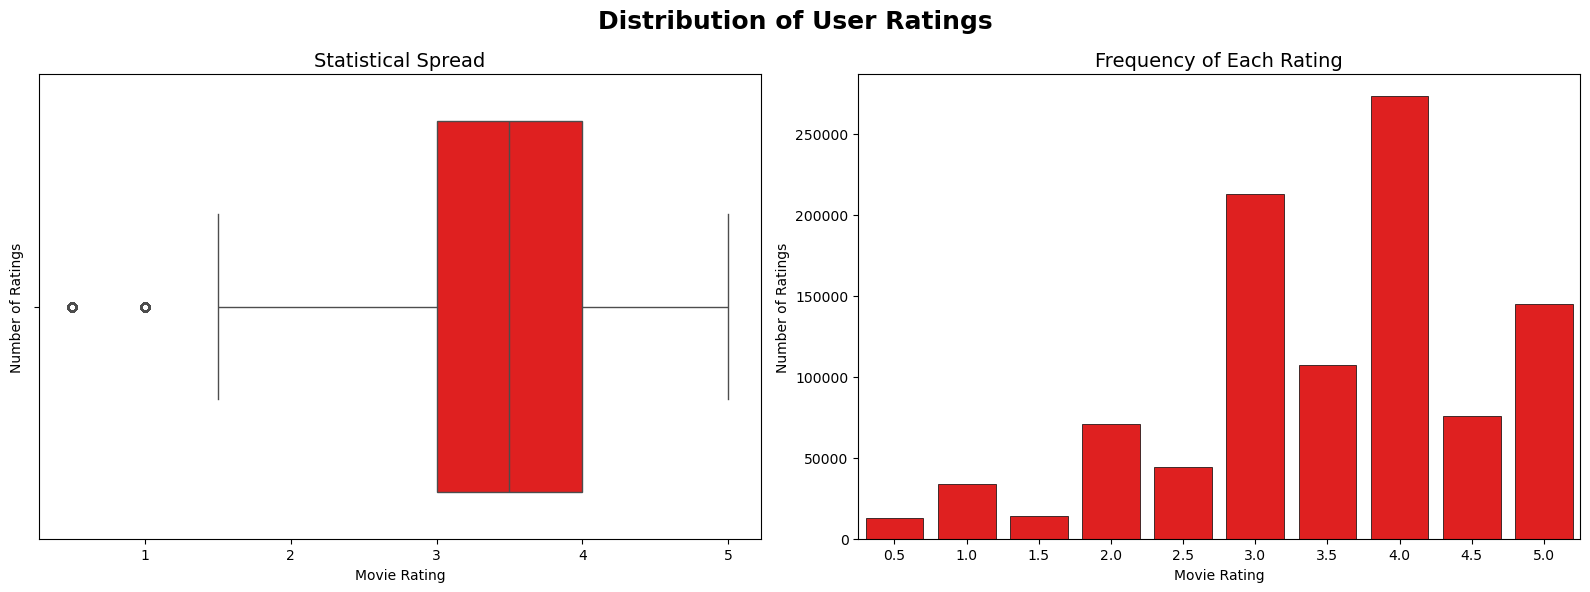

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=ax[0], data=ratings, x='rating',  color = 'r')
ax[0].set_title('Statistical Spread', fontsize=14)
ax[0].set_xlabel("Movie Rating")
ax[0].set_ylabel("Number of Ratings")

sns.countplot(ax=ax[1], data=ratings, x='rating', color = 'r', edgecolor='black', linewidth=0.5)
ax[1].set_title('Frequency of Each Rating', fontsize=14)
ax[1].set_xlabel("Movie Rating")
ax[1].set_ylabel("Number of Ratings")

fig.suptitle('Distribution of User Ratings', fontsize=18, fontweight='bold')

plt.tight_layout()

In [50]:
ratings_per_user = ratings.groupby('userId').size().reset_index(name='num_ratings').sort_values(by='num_ratings', ascending=False)

In [55]:
print("Top 10 most active users")
ratings_per_user.head(10)

Top 10 most active users


,userId,num_ratings
4619,92011,3833
2327,46470,3760
6032,120575,3493
3523,70201,3099
6396,128258,2740
5710,113668,2691
1681,33736,2458
2998,59407,2296
1450,29499,2133
3359,66836,2122


In [11]:
ratings_per_user['num_ratings'].describe()

count    6914.000000
mean      143.118745
std       229.878490
min        20.000000
25%        33.000000
50%        66.000000
75%       150.000000
max      3833.000000
Name: num_ratings, dtype: float64

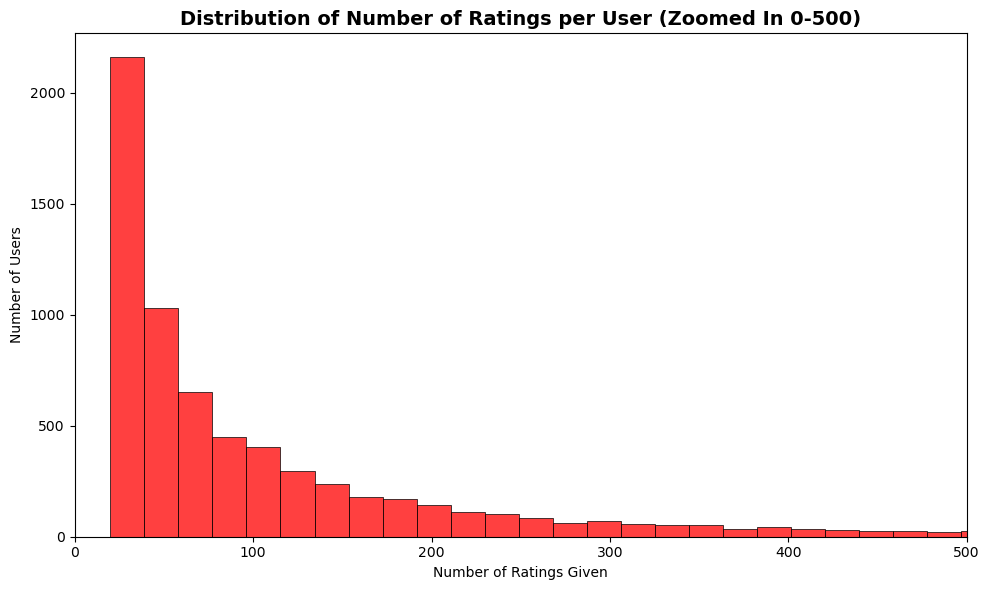

In [93]:
plt.figure(figsize=(10, 6))

sns.histplot(data=ratings_per_user, x='num_ratings', bins=200, color='r', edgecolor='black', linewidth=0.5)

plt.xlim(0, 500)

plt.title('Distribution of Number of Ratings per User (Zoomed In 0-500)', fontsize=14, weight='bold')
plt.xlabel('Number of Ratings Given')
plt.ylabel('Number of Users')

plt.tight_layout()

In [98]:
avg_user_rating = ratings.groupby('userId')['rating'].mean().reset_index(name='avg_rating')

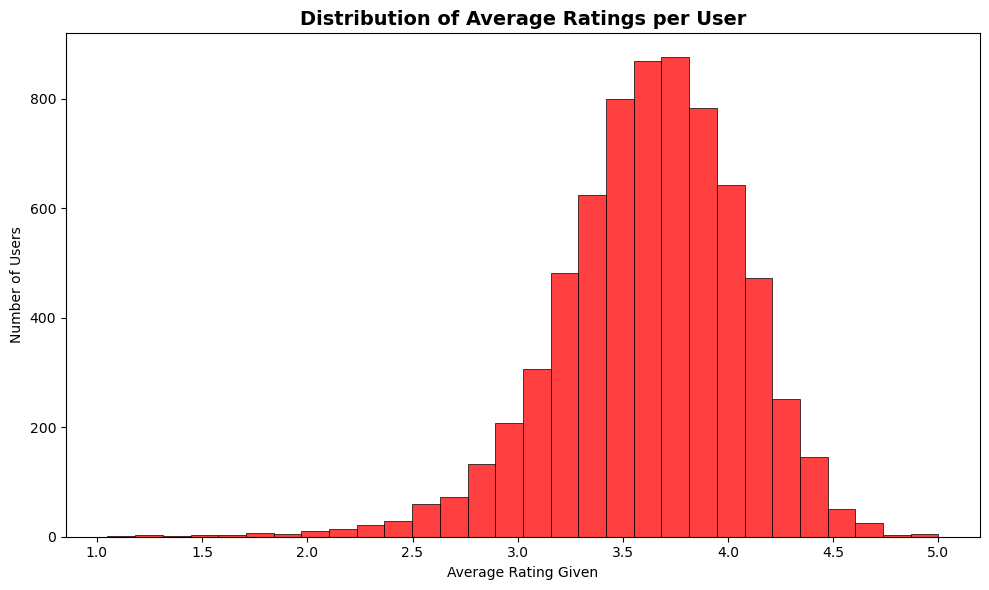

In [123]:
plt.figure(figsize=(10, 6))

sns.histplot(data=avg_user_rating, x='avg_rating', bins=30, color='r', edgecolor='black', linewidth=0.5)

plt.title('Distribution of Average Ratings per User', fontsize=14, weight='bold')
plt.xlabel('Average Rating Given')
plt.ylabel('Number of Users')

plt.tight_layout()

In [13]:
genre_counts = {}

for x in movies['genres']:
    for y in x:
        if y in genre_counts:
            genre_counts[y] += 1
        else:
            genre_counts[y] = 1

In [53]:
count_per_genre = (
    pd.DataFrame.from_dict(genre_counts, orient='index')
    .reset_index()
    .sort_values(by=0, ascending=False)
    .rename(columns={"index" : "genre", 0: "count"})
)

In [15]:
count_per_genre.head(10)

,genre,count
6,Drama,4494
3,Comedy,3358
9,Thriller,1804
5,Romance,1598
7,Action,1589
8,Crime,1155
0,Adventure,1095
10,Horror,894
12,Sci-Fi,820
4,Fantasy,654


In [16]:
print(f"We have {len(count_per_genre)} unique genres.")

We have 19 unique genres.


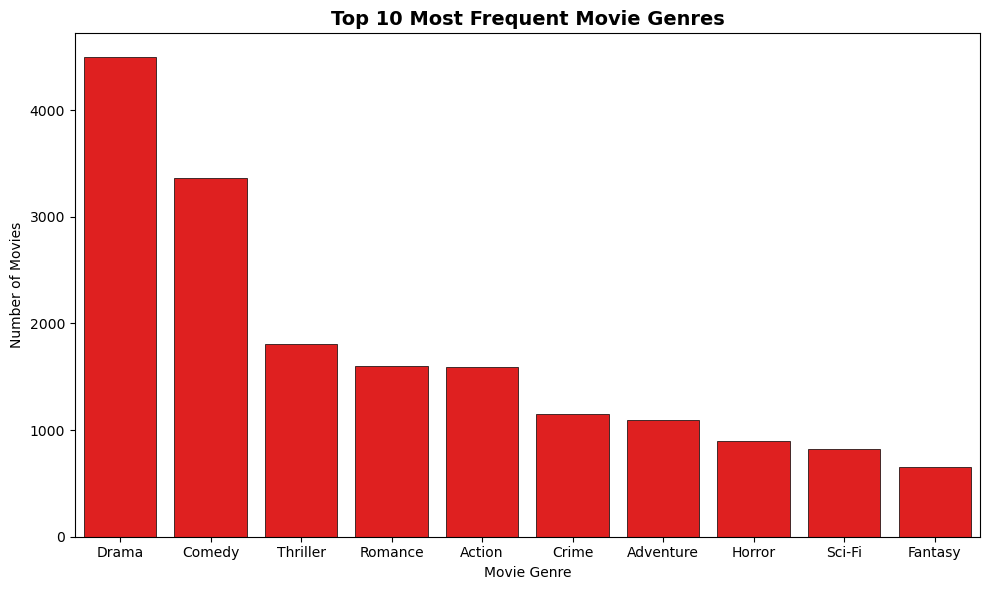

In [92]:
plt.figure(figsize=(10, 6))

sns.barplot(data=count_per_genre.head(10), x='genre', y='count', color='r', edgecolor='black', linewidth=0.5)

plt.title("Top 10 Most Frequent Movie Genres", fontsize=14, weight='bold')
plt.xlabel("Movie Genre")
plt.ylabel("Number of Movies")

plt.tight_layout()

In [107]:
movies_exploded = movies.explode('genres')

In [110]:
genre_ratings = ratings.merge(movies_exploded, on='movieId')

In [111]:
genre_stats = genre_ratings.groupby('genres').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

In [116]:
top_rated_genres = genre_stats.sort_values(by='avg_rating', ascending=False).head(10)

In [117]:
top_rated_genres

,genres,avg_rating,num_ratings
9,Film-Noir,3.960317,10773
17,War,3.809207,51582
6,Documentary,3.724035,11400
7,Drama,3.675088,438457
5,Crime,3.670329,163020
13,Mystery,3.663197,77238
11,IMAX,3.653626,24283
2,Animation,3.614030,56472
18,Western,3.567388,21213
12,Musical,3.564981,42897


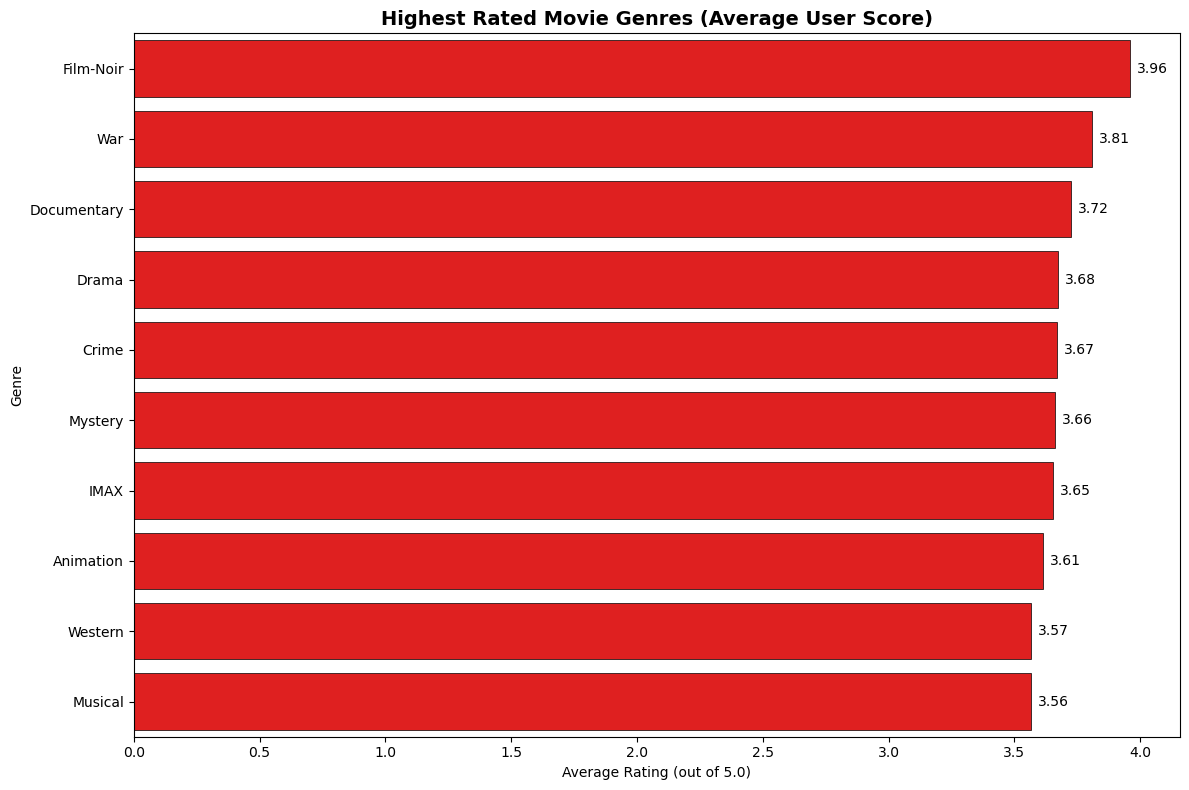

In [122]:
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top_rated_genres, 
    y='genres', 
    x='avg_rating', 
    color='r', 
    edgecolor='black', 
    linewidth=0.5
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=5, fontsize=10)

plt.title('Highest Rated Movie Genres (Average User Score)', fontsize=14, weight='bold')
plt.xlabel('Average Rating (out of 5.0)')
plt.ylabel('Genre')

plt.tight_layout()

In [60]:
ratings_per_film = ratings.groupby('movieId').size().reset_index(name='num_ratings').sort_values(by='num_ratings', ascending=False)

In [61]:
ratings_per_film

,movieId,num_ratings
273,296,3310
332,356,3227
544,593,3137
295,318,3126
444,480,2944
...,...,...
102,108,5
7136,45664,5
7132,45506,5
403,439,4


Note: Due to filtering inactive users after unpopular films, the minimum ratings per item slightly dropped from 5 to 4, which is acceptable for the model.

In [66]:
top_10_films = ratings_per_film.head(10).merge(movies, on='movieId', how='left')

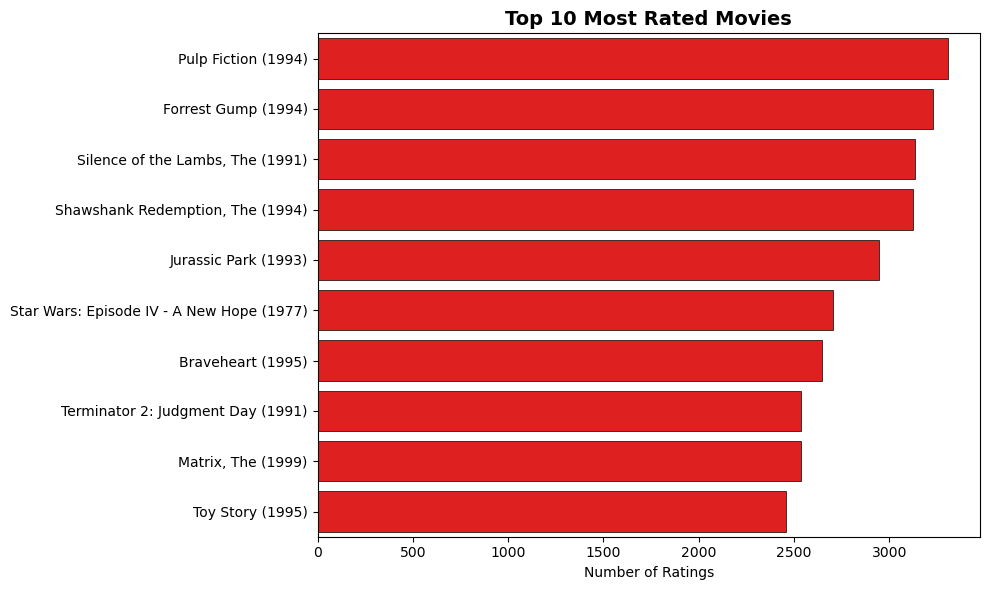

In [95]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_10_films, y='title', x='num_ratings', color='r', edgecolor='black', linewidth=0.5)

plt.title('Top 10 Most Rated Movies', fontsize=14, weight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('')

plt.tight_layout()

## Sparsity & Density

In [7]:
n_users = ratings['userId'].nunique()

In [8]:
n_movies = movies['movieId'].nunique()

In [21]:
n_interactions = len(ratings)

In [29]:
print(f"We have {n_users} unique users and {n_movies} unique films. Total number of ratings: {n_interactions}")

We have 6914 unique users and 9222 unique films. Total number of ratings: 989523


In [27]:
total_possible = n_movies * n_users # Maximum possible number of ratings

In [36]:
density = np.round((n_interactions/total_possible)*100, 2) # % of filled cells in user-item matrix

In [37]:
sparsity = np.round((1-(n_interactions/total_possible))*100, 2) # % of empty cells in user-item matrix

In [35]:
print(f"Matrix Density (% of filled cells): {density}%")

Matrix Density (% of filled cells): 1.55%
